<a href="https://colab.research.google.com/github/iam7mza/EventClassification/blob/main/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# # Downloading the dataset from GitHub (uncomment when running on Colab)
# !git clone "https://github.com/iam7mza/EventClassification.git"
# !mv EventClassification/* ./
# !rm -rf EventClassification
# !rm -rf sample_data



############# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! no touch zone !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! #############
#importing data

import loader
import numpy as np
import pandas as pd

filepath = "csv_output" 
df = loader.load(filepath);
loader.clean(df); #to clean the data

df = df[df['numeric_target'] != -1]  #dropping all the unknown events

# Check unique event types and their corresponding targets
event_target_mapping = df[['event_type', 'numeric_target']].drop_duplicates().sort_values('numeric_target')
print("Event type to target mapping:")
print(event_target_mapping)

print(f'columns = {df.columns}')

############################################################
#########extracing features and values from lists###########
#############################################################`

# the chosen ones
# TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
#        'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
#        'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
#        'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
#        'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
#        'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
#        'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
#        'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
#        'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m', 'lep_pt_syst',
#        'met_et_syst', 'jet_pt_syst', 'photon_pt_syst', 'largeRjet_pt_syst',
#        'tau_pt_syst']


TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
       'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
       'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
       'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
       'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
       'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
       'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
       'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
       'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m']

#df[TheChosenOnes]

#extracting the features for lists (only first two elements)

#TODO: Turn into a function and make the number of cols an arg
# Separate list and scalar columns

def extract_list_features(df, list_cols, scalar_cols, n_elements=2):
    """
    Extract features from list columns with configurable number of elements.

    Parameters:
    df: DataFrame containing the data
    list_cols: List of column names that contain lists
    scalar_cols: List of column names that contain scalar values
    n_elements: Number of elements to extract from each list (max 5)

    Returns:
    DataFrame with extracted features
    """
    # Ensure n_elements is within valid range
    n_elements = min(max(n_elements, 1), 5)

    # Element names for readability
    element_names = ['first', 'second', 'third', 'fourth', 'fifth']

    extracted_data = {}

    # Add scalar columns
    for col in scalar_cols:
        extracted_data[col] = df[col]

    # Add list-derived columns
    for col in list_cols:
        for i in range(n_elements):
            col_name = f'{col}_{element_names[i]}'
            extracted_data[col_name] = df[col].apply(
                lambda x: x[i] if len(x) > i else np.nan
            )

    return pd.DataFrame(extracted_data)

# Usage with configurable number of elements
n_elements = 5  # Change this to extract 1-5 elements from each list

# Separate list and scalar columns
list_cols = []
scalar_cols = []

for col in TheChosenOnes:
    if col in df.columns:
        if isinstance(df[col].iloc[0], list):  # Use iloc[0] instead of [0]
            list_cols.append(col)
        else:
            scalar_cols.append(col)

print(f"List columns: {len(list_cols)}")
print(f"Scalar columns: {len(scalar_cols)}")
print(f"Extracting {n_elements} elements from each list column")

# Extract features with specified number of elements
df_extracted = extract_list_features(df, list_cols, scalar_cols, n_elements)

print(f"Shape after feature extraction: {df_extracted.shape}")

# Drop columns that are all zeros or nan
columns_to_drop = []
for col in df_extracted.columns:
    if df_extracted[col].isna().all():  # nan check
        columns_to_drop.append(col)
        print(f"Column {col} is all NaN, will drop it.")
    elif (df_extracted[col] == 0).all():  # zero check
        columns_to_drop.append(col)
        print(f"Column {col} is all zeros, will drop it.")


# Drop all NaN columns at once
if columns_to_drop:
    df_extracted = df_extracted.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} NaN columns")

print(f"Final shape: {df_extracted.shape}")
df_extracted

################################################################
## remving zero heavy columns ##################################
################################################################

# First, let's see what columns with _first we have
first_cols = [col for col in df_extracted.columns if '_first' in col]
print("Columns with '_first':")
print(first_cols)

# Features to compute TOTAL (sum)
total_base_features = ['lep_pt', 'lep_E', 'lep_charge', 'lep_ptcone30', 'lep_etcone20',
                      'jet_pt', 'jet_E', 'largeRjet_pt', 'largeRjet_E', 'largeRjet_m']

# Features to compute MEAN (average)
mean_base_features = ['lep_eta', 'lep_phi', 'lep_z0', 'jet_eta', 'jet_phi',
                     'largeRjet_eta', 'largeRjet_phi', 'lep_pt_syst', 'jet_pt_syst',
                     'largeRjet_pt_syst']

element_indicators = ['_first', '_second', '_third', '_fourth', '_fifth']

print("\nCreating TOTAL columns:")
# Create total columns
for base_feature in total_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        total_col_name = f'{base_feature}_total'
        df_extracted[total_col_name] = df_extracted[feature_cols].sum(axis=1)
        print(f"  {total_col_name} from {len(feature_cols)} columns: {feature_cols}")

print("\nCreating MEAN columns:")
# Create mean columns
for base_feature in mean_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        mean_col_name = f'{base_feature}_mean'
        # Calculate mean excluding zeros to avoid bias from missing particles

        ##TODO: Im not sure if replacing 0 with NaN is the best way to calculate mean here
        df_extracted[mean_col_name] = df_extracted[feature_cols].replace(0, np.nan).mean(axis=1, skipna=True).fillna(0)
        print(f"  {mean_col_name} from {len(feature_cols)} columns: {feature_cols}")

print(f"\nShape after adding totals and means: {df_extracted.shape}")

# Show new columns created
new_total_cols = [col for col in df_extracted.columns if '_total' in col]
new_mean_cols = [col for col in df_extracted.columns if '_mean' in col]
print(f"Added {len(new_total_cols)} total columns and {len(new_mean_cols)} mean columns")
print(f"Total columns: {new_total_cols}")
print(f"Mean columns: {new_mean_cols}")


############################################################
########### dropping nan heavy rows ########################
############################################################
#TODO: create cols with total values (for pt, E, et, etc.) such that when some cols are dropped, the total still exists

percentlim = 0.1  # 10% limit
nan_fraction = df_extracted.isna().mean(axis=0)  # Fraction of NaN values per column
high_nan_cols = nan_fraction[nan_fraction > percentlim].index.tolist()
print(f'{len(high_nan_cols)} cols are more than {percentlim*100:.0f}% NaN out of {len(df_extracted.columns)}')
print("NaN fractions per column:")
for col, frac in zip(df_extracted.columns, nan_fraction):
    if frac > 0:  # Only show columns with some NaN values
        print(f"  {col}: {frac*100:.1f}%")

df_extracted = df_extracted.drop(high_nan_cols, axis=1)
print(f'Columns remaining after dropping high-NaN columns: {len(df_extracted.columns)}')

df_extracted

#Dropping nan rows (if they exist)

nan_counts = df_extracted.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(f"Columns with NaN values ({len(columns_with_nan)} out of {len(nan_counts)}):")
if len(columns_with_nan) > 0:
    for col, count in columns_with_nan.items():
        print(f"  {col}: {count}")
else:
    print("No columns have NaN values! YIPPIEEE!!")

# FIXED: Drop the same rows from both features AND targets
print(f"Shape before dropping NaN rows: {df_extracted.shape}")
rows_before = len(df_extracted)

# Get mask for rows WITHOUT any NaN values
valid_rows_mask = ~df_extracted.isna().any(axis=1)

# Apply the same mask to BOTH dataframes
df_extracted = df_extracted[valid_rows_mask]
df = df[valid_rows_mask]  # Drop same rows from targets!

rows_after = len(df_extracted)
print(f"Shape after dropping NaN rows: {df_extracted.shape}")
print(f"Dropped {rows_before - rows_after} rows with NaN values")
print(f"Target dataframe shape: {df.shape}")

# Verify alignment
print(f"Features and targets are aligned: {len(df_extracted) == len(df)}")




Found 85 CSV files
Processing: csv_output/Wenu_PTV280_500_CVetoBVeto_sample2000.csv
  -> Added 2000 events (event name: Wenu_PTV280_500_CVetoBVeto)
Processing: csv_output/ZPrime2250_tt_sample2000.csv
  -> Added 2000 events (event name: ZPrime2250_tt)
Processing: csv_output/Wenu_PTV140_280_CFilterBVeto_sample2000.csv
  -> Added 2000 events (event name: Wenu_PTV140_280_CFilterBVeto)
Processing: csv_output/Wmunu_PTV140_280_BFilter_sample2000.csv
  -> Added 2000 events (event name: Wmunu_PTV140_280_BFilter)
Processing: csv_output/single_antitop_wtchan_sample2000.csv
  -> Added 2000 events (event name: single_antitop_wtchan)
Processing: csv_output/Wmunu_PTV140_280_CVetoBVeto_sample2000.csv
  -> Added 2000 events (event name: Wmunu_PTV140_280_CVetoBVeto)
Processing: csv_output/Wmunu_PTV1000_E_CMS_sample2000.csv
  -> Added 2000 events (event name: Wmunu_PTV1000_E_CMS)
Processing: csv_output/Wenu_PTV140_280_CVetoBVeto_sample2000.csv
  -> Added 2000 events (event name: Wenu_PTV140_280_CVetoBVet

## CORR optimization

In [2]:
from sklearn.preprocessing import QuantileTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


corr_list = [0.99, 0.95, 0.90, 0.85]  # List of correlation thresholds to check
DNN_Histories = ['corr', 'History']

for c in corr_list:
    print(f"Checking correlation threshold: {c}")
    
    
    print(f'number of initial features: {len(df_extracted.columns)}')
    corr = df_extracted.corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Find features with correlation greater than 0.7
    to_drop = [column for column in upper.columns if any(upper[column] > c)]
    # print('cols to drop:' + str(to_drop))
    # Drop features 
    df_new = df_extracted.copy()  # Create a copy to avoid modifying original df_extracted
    df_new.drop(to_drop, axis=1, inplace=True)

    corr2 = df_new.corr().abs()
    print(f'number of final features:{len(df_new.columns)}')


    # Scaling
    qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000) #TODO: try uniform distribution
    X_scaled = qt.fit_transform(df_new)

    # Train Test Split
    from sklearn.model_selection import train_test_split
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['numeric_target'], test_size=0.2, random_state=42, stratify=df['numeric_target'])

    num_classes = len(df['numeric_target'].unique())


    # Define the model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    ES = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[ES])

    DNN_Histories.append([c, history])



2025-07-10 00:29:38.712537: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 00:29:38.885559: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 00:29:39.056035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752100179.187078   17107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752100179.224195   17107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752100179.540968   17107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Checking correlation threshold: 0.99
number of initial features: 74
number of final features:74


2025-07-10 00:29:54.960641: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.5342 - loss: 1.1141 - val_accuracy: 0.5994 - val_loss: 0.9358
Epoch 2/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5928 - loss: 0.9682 - val_accuracy: 0.6001 - val_loss: 0.9236
Epoch 3/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6000 - loss: 0.9475 - val_accuracy: 0.6092 - val_loss: 0.9134
Epoch 4/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6086 - loss: 0.9335 - val_accuracy: 0.6047 - val_loss: 0.9134
Epoch 5/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6095 - loss: 0.9254 - val_accuracy: 0.6161 - val_loss: 0.9052
Epoch 6/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6164 - loss: 0.9192 - val_accuracy: 0.6153 - val_loss: 0.9013
Epoch 7/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6145 - loss: 0.9183 - val_accuracy: 0.6164 - val_loss: 0.8875
Epoch 8/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6221 -

2025-07-10 01:07:42.148996: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22487040 exceeds 10% of free system memory.


2880/2880 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.5359 - loss: 1.1043 - val_accuracy: 0.5931 - val_loss: 0.9409
Epoch 2/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5923 - loss: 0.9636 - val_accuracy: 0.5983 - val_loss: 0.9212
Epoch 3/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6004 - loss: 0.9491 - val_accuracy: 0.6024 - val_loss: 0.9250
Epoch 4/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6068 - loss: 0.9336 - val_accuracy: 0.6136 - val_loss: 0.9039
Epoch 5/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6079 - loss: 0.9318 - val_accuracy: 0.6140 - val_loss: 0.9069
Epoch 6/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6129 - loss: 0.9229 - val_accuracy: 0.6138 - val_loss: 0.8959
Epoch 7/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6150 - loss: 0.9175 - val_accuracy: 0.6172 - val_loss: 0.9013
Epoch 8/100
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6156 - loss: 0.912

In [3]:
def get_stable_val_accuracy(val_acc, method='mean_around_peak', window=5):
    """Get a stable validation accuracy metric that's less sensitive to fluctuations"""
    
    if method == 'mean_around_peak':
        maxindex = np.argmax(val_acc)
        # Safe indexing to avoid out-of-bounds
        start_idx = max(0, maxindex - window)
        end_idx = min(len(val_acc), maxindex + window + 1)
        
        stable_acc = np.mean(val_acc[start_idx:end_idx])
        stability_std = np.std(val_acc[start_idx:end_idx])
        
    return stable_acc, stability_std

# Extract data for plotting
correlation_values = []
val_accuracies = []
std_values = []

for i, H in enumerate(DNN_Histories[2:]):
    if i >= 4:
        break
    
    # Extract hyperparameters
    correlation_value = H[0]  # First hyperparameter
    
    # Get validation accuracy
    val_acc = H[1].history['val_accuracy']
    stable_acc, stability_std = get_stable_val_accuracy(val_acc, method='mean_around_peak', window=5)
    
    correlation_values.append(correlation_value)
    val_accuracies.append(stable_acc)
    std_values.append(stability_std)

# Convert to numpy arrays
correlation_values = np.array(correlation_values)
val_accuracies = np.array(val_accuracies)
std_values = np.array(std_values)


print(f'correlation cut = {correlation_values}')
print(f'val acc = {val_accuracies}')
print(f'std = {std_values}')

correlation cut = [0.99 0.95 0.9  0.85]
val acc = [0.64076704 0.63917299 0.63951514 0.63971353]
std = [0.00322697 0.00262782 0.00255439 0.00229296]


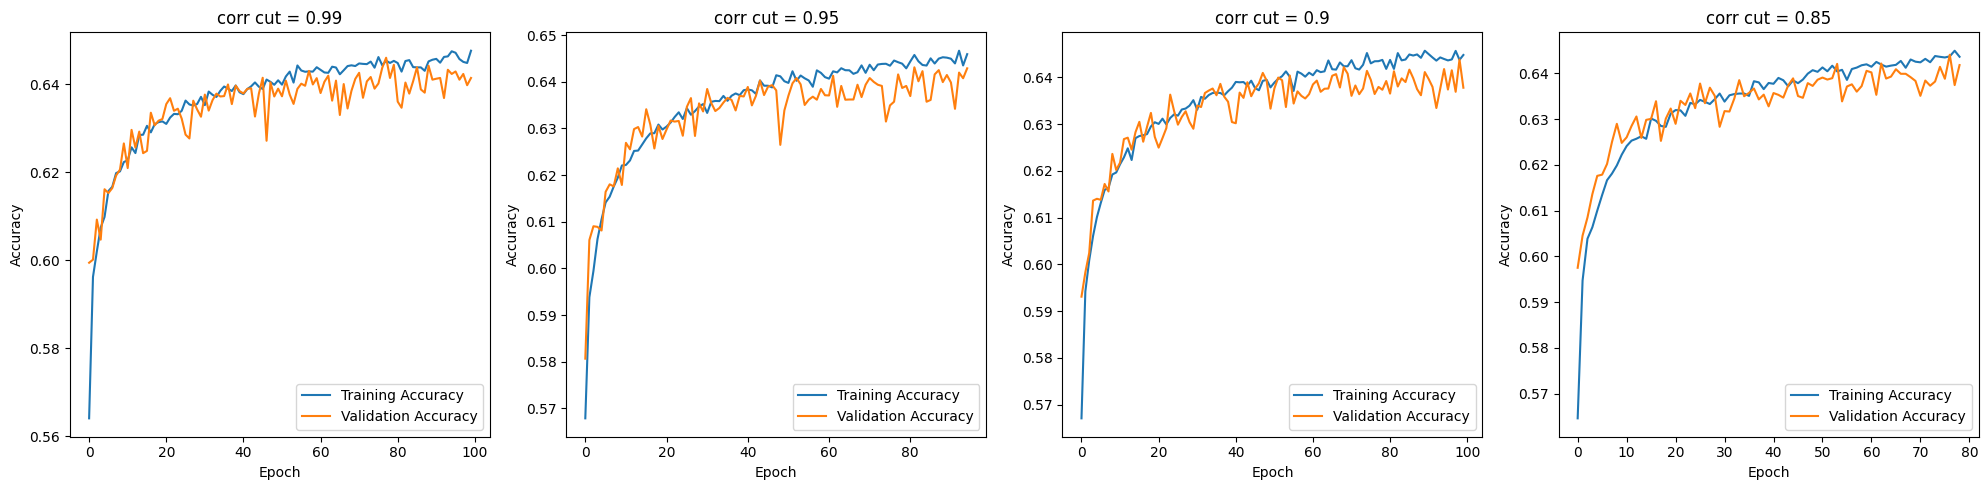

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax = ax.flatten()  # Convert 2D array to 1D for easier indexing

for i, H in enumerate(DNN_Histories[2:]):
    if i >= 5:  # Safety check for 3x3 grid
        break
    ax[i].plot(H[1].history['accuracy'], label='Training Accuracy')
    ax[i].plot(H[1].history['val_accuracy'], label='Validation Accuracy')
    ax[i].legend()
    ax[i].set_title(f'corr cut = {H[0]}')
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy')


plt.tight_layout()
plt.show()

Text(0, 0.5, 'Val Accuracy')

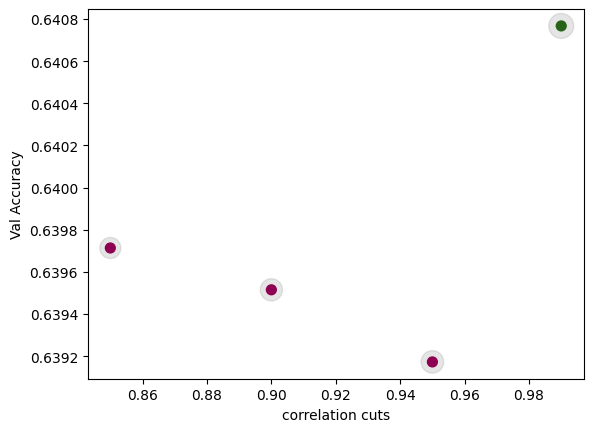

In [5]:
plt.scatter(correlation_values, val_accuracies, alpha = 0.2, s = 10e4*std_values, color = 'grey', label = 'std')
c = (np.ones(val_accuracies.size) + (val_accuracies == np.max(val_accuracies)))
plt.scatter(correlation_values, val_accuracies, s = 50, c=c, cmap='PiYG')
plt.xlabel('correlation cuts')
plt.ylabel('Val Accuracy')
# plt.set_xscale('log')
